##Arrays

In [ ]:
import numpy as np
arr = np.array([10, 20, 30, 40, 50])
print(arr)

[10 20 30 40 50]


##2D Array

In [ ]:
arr2 = np.array([
    [1, 2, 3],
    [4, 5, 6]
])
print(arr2)

[[1 2 3]
 [4 5 6]]


##Vectorization

In [ ]:
arr = np.array([1, 2, 3])
print(arr * 2, arr + 4)

[2 4 6] [5 6 7]


##Indexing & Slicing

In [ ]:
arr = np.array([2, 4, 6, 8])
print(arr[0], arr[1], arr[-1], arr[1:4])

2 4 8 [4 6 8]


In [ ]:
matrix = np.array([
    [1, 2, 4],
    [5, 6, 8]
])
print(matrix[0,1])

2


##Pandas

In [24]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##Filtering Data

In [27]:
first_class = df[
    df["Pclass"] == 1
    ]

print(first_class.head())




    PassengerId  Survived  Pclass  \
1             2         1       1   
3             4         1       1   
6             7         0       1   
11           12         1       1   
23           24         1       1   

                                                 Name     Sex   Age  SibSp  \
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
6                             McCarthy, Mr. Timothy J    male  54.0      0   
11                           Bonnell, Miss. Elizabeth  female  58.0      0   
23                       Sloper, Mr. William Thompson    male  28.0      0   

    Parch    Ticket     Fare Cabin Embarked  
1       0  PC 17599  71.2833   C85        C  
3       0    113803  53.1000  C123        S  
6       0     17463  51.8625   E46        S  
11      0    113783  26.5500  C103        S  
23      0    113788  35.5000    A6        S  


In [28]:
result = df[
    (df["Sex"] == "female") & (df["Age"] > 25)
    ]

print(result.head())

    PassengerId  Survived  Pclass  \
1             2         1       1   
2             3         1       3   
3             4         1       1   
8             9         1       3   
11           12         1       1   

                                                 Name     Sex   Age  SibSp  \
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                              Heikkinen, Miss. Laina  female  26.0      0   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
8   Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)  female  27.0      0   
11                           Bonnell, Miss. Elizabeth  female  58.0      0   

    Parch            Ticket     Fare Cabin Embarked  
1       0          PC 17599  71.2833   C85        C  
2       0  STON/O2. 3101282   7.9250   NaN        S  
3       0            113803  53.1000  C123        S  
8       2            347742  11.1333   NaN        S  
11      0            113783  26.5500  

##Grouping Data

In [29]:
fare = df.groupby("Pclass")["Fare"].mean()

print(fare)

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [30]:
result = df.groupby(["Pclass", "Sex"])["Fare"].mean()

print(result)

Pclass  Sex   
1       female    106.125798
        male       67.226127
2       female     21.970121
        male       19.741782
3       female     16.118810
        male       12.661633
Name: Fare, dtype: float64


##Handling Missing Values

In [41]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [32]:
df.shape

(891, 12)

In [37]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
print(df["Age"])
df['Age'].isnull().sum()

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64


np.int64(0)

In [39]:
df['Cabin'] = df['Cabin'].fillna("Unknown")
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [40]:
#clean_df = df.dropna() Removing the rows with missing values
#df = df.drop(columns=["Cabin"]) Removing columns with missing values

##Matplotlib / Seaborn

###1. Histogram
Reveals:

* Which age groups are most common
* Whether data is symmetric or skewed
* Presence of outliers
* Spread of the data







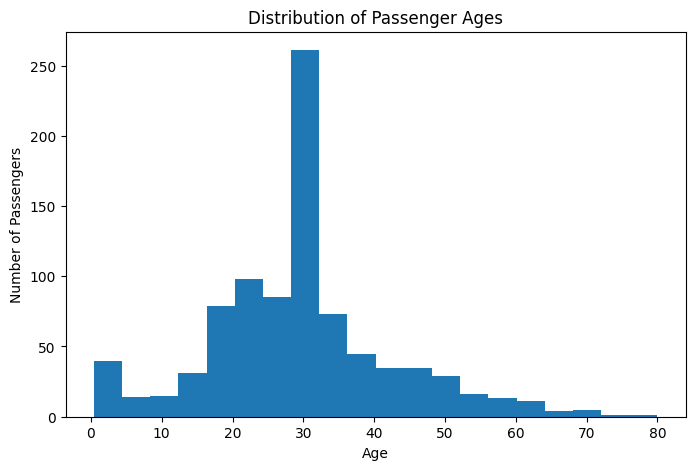

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
plt.hist(df["Age"].dropna(), bins=20)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

###2. Bar Chart
Reveals:

* Category frequencies
* Comparison between groups
* Highest and lowest categories




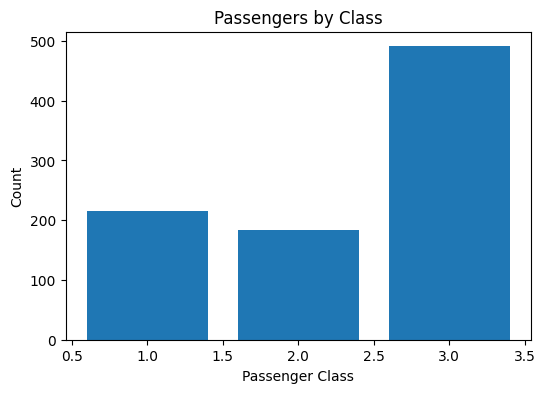

In [43]:
class_counts = df["Pclass"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(class_counts.index, class_counts.values)

plt.title("Passengers by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

###3. Scatter Plot
Reveals:

* Positive/negative relationships
* Clusters
* Outliers
* Correlation trends







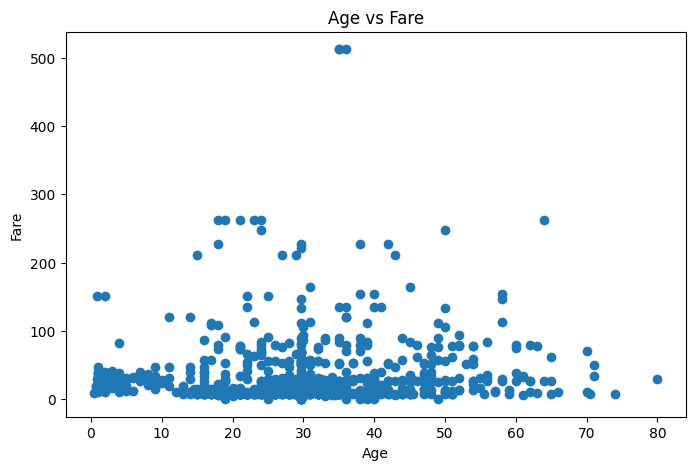

In [44]:
plt.figure(figsize=(8,5))
plt.scatter(df["Age"], df["Fare"])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

###4. Box Plot
Reveals:
* Median
* Quartiles
* Spread
* Extreme values (outliers)






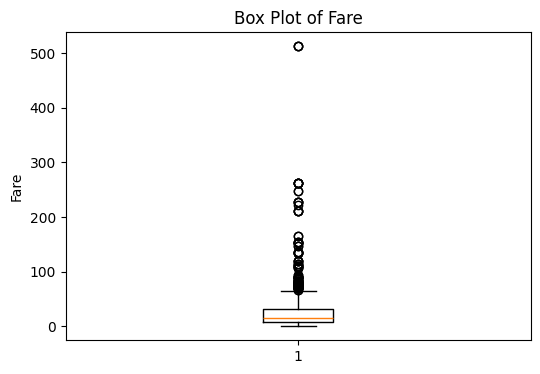

In [45]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Fare"].dropna())

plt.title("Box Plot of Fare")
plt.ylabel("Fare")

plt.show()

###5. Heatmap
Reveals:

* Strong positive relationships
* Strong negative relationships
* Variables with little or no relationship

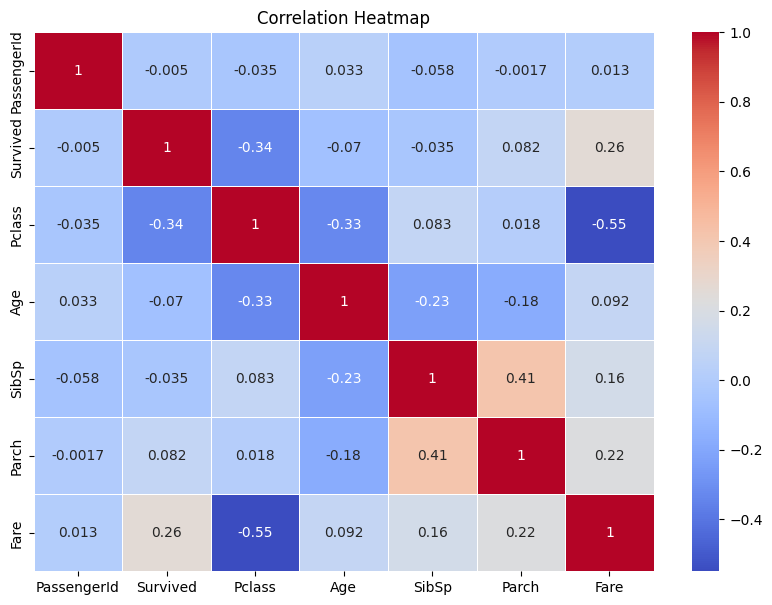

In [46]:
numeric_df = df.select_dtypes(include=["number"])

corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(10,7))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

##Standard Deviation (Std)
Reveals:

* How spread out the values are around the mean.

Small standard deviation:

* Values are close to the average.

Large standard deviation:

* Values are widely spread.



In [47]:
print(df["Age"].std())

13.002015226002884


##Correlation
Reveals:

* Positive values → variables increase together.
* Negative values → one increases while the other decreases.
* Near 0 → little or no linear relationship.







In [48]:
print(df[["Age", "Fare"]].corr())

           Age      Fare
Age   1.000000  0.091566
Fare  0.091566  1.000000
